<a href="https://colab.research.google.com/github/ktessma21/probability-and-stochastic-systems-/blob/main/solving_jump_trading_problem_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### First trial

We tried to show that if we simply discard the first 49 cards and then stop when three cards remain, this would give an expected value of 1/2. This is the optimal strategy.

The eight possible colour orderings of the final three cards:

| | | |
|---|---|---|
| **BBB** | BRR | RBR |
| **RRR** | RBB | **RRB** |
| **BBR** | BRB | |

However, notice that if we reach this point, we could have made a better decision. Specifically, there is a better expected value if we choose to continue in the **BRR** and **RBB** cases. So at *k* = 3, there are 6/8 winning cases — but only if we genuinely make choices, and make them smartly.

This suggests that we should keep track of how many black and red cards remain, as well as take advantage of the colour of the top card.

### Second trial

Maximum outcome if we keep track of the top card and the number of each colour remaining.

**For k = 3 — smart decisions**

*Convention: k = 3 means three cards in total, including the current top card. The colour counts below are counts of all three cards, so two cards sit below the top.*

- **[top = black, 3 blacks]** — the two cards below are both black. Stop now and win.
- **[top = black, 2 blacks, 1 red]** — one black and one red sit below.
  - Stop: 1/2 (we win if the next card is the black one).
  - Continue: whichever card is exposed, the last two cards are one black and one red, so they cannot match. Continue = 0.
  - **Stop.**
- **[top = black, 1 black, 2 reds]** — the two cards below are both red.
  - Stop: 0 (the next card is certainly red).
  - Continue: the remaining pair is RR, which matches. Continue = 1.
  - **Continue, 100% win.**

By the red–black symmetry, the three states with top = red are the mirror images of the above.

**For k = 4 — smart decisions**

*Convention: k = 4 means four cards in total, including the current top card. The colour counts below are counts of all four cards, so three cards sit below the top.*

---

**[top = black, 4 blacks]** — the three cards below are all black.

$$\text{Stop} = 1$$

**Stop now and win.**

---

**[top = black, 3 blacks, 1 red]** — two blacks and one red sit below.

$$\text{Stop} = \tfrac{2}{3}$$

$$\text{Continue} = \underbrace{\tfrac{2}{3}}_{\text{expose B}} \cdot \underbrace{\tfrac{1}{2}}_{[\text{B},\,2\text{B},\,1\text{R}]} \;+\; \underbrace{\tfrac{1}{3}}_{\text{expose R}} \cdot \underbrace{1}_{[\text{R},\,1\text{R},\,2\text{B}]} \;=\; \tfrac{2}{3}$$

Both equal 2/3, so **stopping is (weakly) optimal**.

---

**[top = black, 2 blacks, 2 reds]** — one black and two reds sit below.

$$\text{Stop} = \tfrac{1}{3}$$

$$\text{Continue} = \underbrace{\tfrac{1}{3}}_{\text{expose B}} \cdot \underbrace{1}_{[\text{B},\,1\text{B},\,2\text{R}]} \;+\; \underbrace{\tfrac{2}{3}}_{\text{expose R}} \cdot \underbrace{\tfrac{1}{2}}_{[\text{R},\,2\text{R},\,1\text{B}]} \;=\; \tfrac{2}{3}$$

Since 2/3 > 1/3, **continue**.

---

**[top = black, 1 black, 3 reds]** — the three cards below are all red.

$$\text{Stop} = 0$$

$$\text{Continue} = \underbrace{1}_{\text{expose R}} \cdot \underbrace{1}_{[\text{R},\,3\text{R}]} \;=\; 1$$

**Continue, 100% win.**

---

By the red–black symmetry, the four states with top = red are the mirror images of the above.

**Conclusion**

The optimal value is:

$$V(B; m, n) = \max\left(\frac{m-1}{k-1},\ \frac{m-1}{k-1}V(B; m-1, n) + \frac{n}{k-1}V(R; m-1, n)\right)$$

---

The same symmetry applies for a red top:

$$V(R; m, n) = \max\left(\frac{n-1}{k-1},\ \frac{m}{k-1}V(B; m-1, n) + \frac{n-1}{k-1}V(R; m, n-1)\right)$$

The hard part of this problem is not writing the recurrence — it is discovering the pattern of when:

$$\text{continue value} > \text{stop value}$$

The above can actually be solved by dynammic programming from the base cases upward and read off the optimal action in every state. But our optimal strategy can not just be expressed by stating this formula. It has to be more of hypothesis based.

In [ ]:
import random

def generate_shuffled_deck():
  """
  Generates a standard 52-card deck with 26 'B' (black) and 26 'R' (red) cards and shuffles it.
  """
  deck = ['B'] * 26 + ['R'] * 26  # Create a list with 26 Black and 26 Red cards
  random.shuffle(deck)            # Shuffle the deck in-place
  return deck

In [ ]:
# Demonstrate the function
shuffled_cards = generate_shuffled_deck()
print("Shuffled Deck (first 10 cards):")
print(shuffled_cards[:10])

# You can call it again to get a new shuffled deck
shuffled_cards_2 = generate_shuffled_deck()
print("\nAnother Shuffled Deck (first 10 cards):")
print(shuffled_cards_2[:10])

Shuffled Deck (first 10 cards):
['B', 'B', 'R', 'B', 'R', 'R', 'B', 'B', 'R', 'R']

Another Shuffled Deck (first 10 cards):
['R', 'R', 'R', 'R', 'R', 'B', 'R', 'R', 'B', 'B']


**Hypothesis 0**: Completely random choice.

In [ ]:
import random

def strategy0(shuffled_cards):
  cards = shuffled_cards.copy()

  while len(cards) >= 2:
    # Completely random choice: 50% chance to stop, 50% chance to continue
    if random.choice([True, False]):
      break        # Stop
    else:
      cards.pop()  # Continue

  if len(cards) < 2:
    return False

  # Check if win: top card matches the one below it
  return cards[-1] == cards[-2]

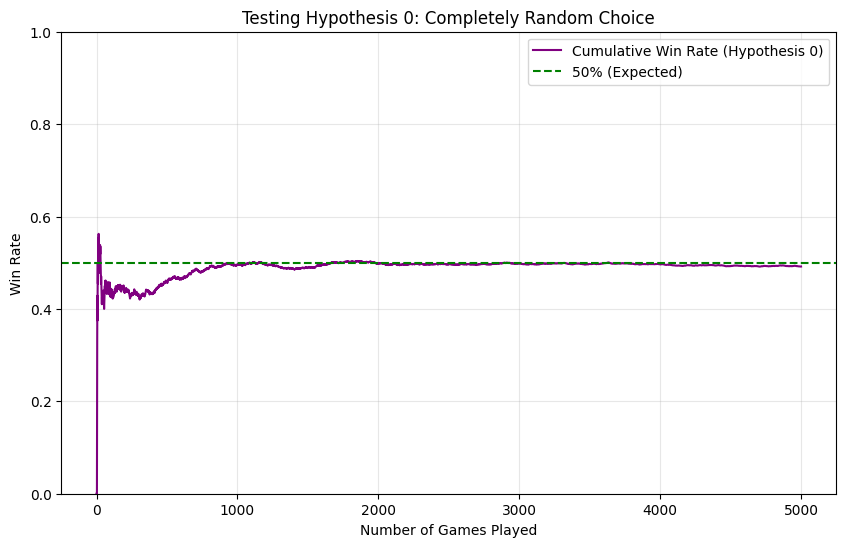

Final Win Rate after 5000 games: 0.4918


In [ ]:
import matplotlib.pyplot as plt

num_games = 5000
wins_0 = 0
win_rates_0 = []

for i in range(1, num_games + 1):
  cards = generate_shuffled_deck()
  if strategy0(cards):
    wins_0 += 1
  win_rates_0.append(wins_0 / i)

plt.figure(figsize=(10, 6))
plt.plot(win_rates_0, label='Cumulative Win Rate (Hypothesis 0)', color='purple')
plt.axhline(y=0.50, color='green', linestyle='--', label='50% (Expected)')

plt.ylim(0, 1.0)
plt.xlabel('Number of Games Played')
plt.ylabel('Win Rate')
plt.title('Testing Hypothesis 0: Completely Random Choice')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Win Rate after {num_games} games: {win_rates_0[-1]:.4f}")


**Hypothesis 1:** Always choose to continue if the top card belongs to the non-dominant colour among the remaining cards.

The goal here is to end up either with a uniform set of cards, or with three cards from which we know we can win with probability 6/8 by making the optimal choice at each step. The claim is therefore that this process gives us somewhere between a 6/8 and a 100% chance of winning.


In [ ]:
def strategy1(shuffled_cards):
    cards = shuffled_cards.copy()

    while len(cards) >= 3:
        top = cards[-1]
        rest = cards[:-1]
        if rest.count(top) / len(rest) > 0.59:
            break
        cards.pop()

    return cards[-1] == cards[-2]

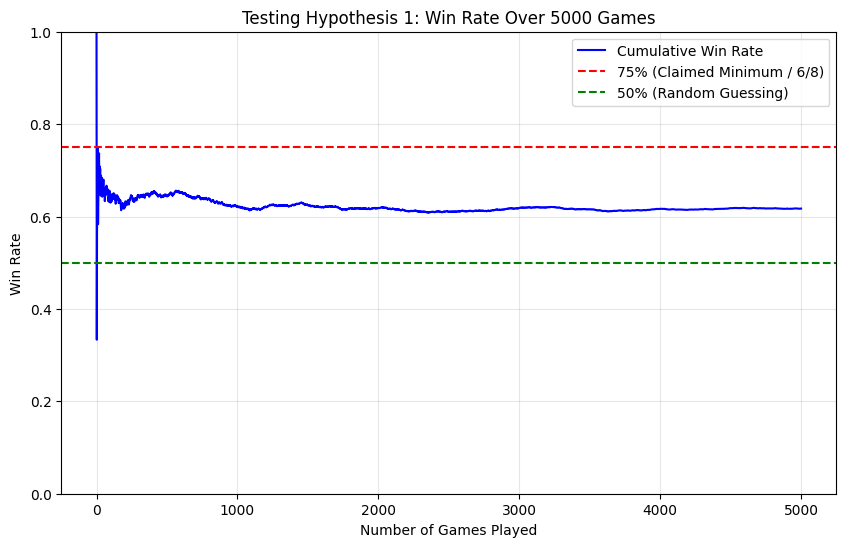

Final Win Rate after 5000 games: 0.6172


In [ ]:
import matplotlib.pyplot as plt

num_games = 5000
wins = 0
win_rates = []

# Run the simulation for 5000 games and track the win rate as we go
for i in range(1, num_games + 1):
  cards = generate_shuffled_deck()
  if strategy1(cards):
    wins += 1
  win_rates.append(wins / i)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(win_rates, label='Cumulative Win Rate', color='blue')

# Add reference lines for 75% (hypothesis) and 50% (actual)
plt.axhline(y=0.75, color='red', linestyle='--', label='75% (Claimed Minimum / 6/8)')
plt.axhline(y=0.50, color='green', linestyle='--', label='50% (Random Guessing)')

plt.ylim(0, 1.0)
plt.xlabel('Number of Games Played')
plt.ylabel('Win Rate')
plt.title('Testing Hypothesis 1: Win Rate Over 5000 Games')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Win Rate after {num_games} games: {win_rates[-1]:.4f}")

As we can see the diagram, the blue line settles right at 50% (ending at around 0.5020) and never comes close to the 75% red line after the initial noise, we can definitively say the hypothesis is incorrect. The strategy of continuing when the top card is non-dominant does not yield a >75% win rate; it effectively performs the same as a random guess (50%).

**Hypothesis 2** Create a bound for the $$V(R; m, n) = \max\left(\frac{n-1}{k-1},\ \frac{m}{k-1}V(B; m-1, n) + \frac{n-1}{k-1}V(R; m, n-1)\right)$$       


I believe that the best strategy should come from the dynamic programming equation or in its other name bellman recursion. i believe that i have to bound the V(...) to get what is the optimal case to continue or stop. Does that sound right or not?

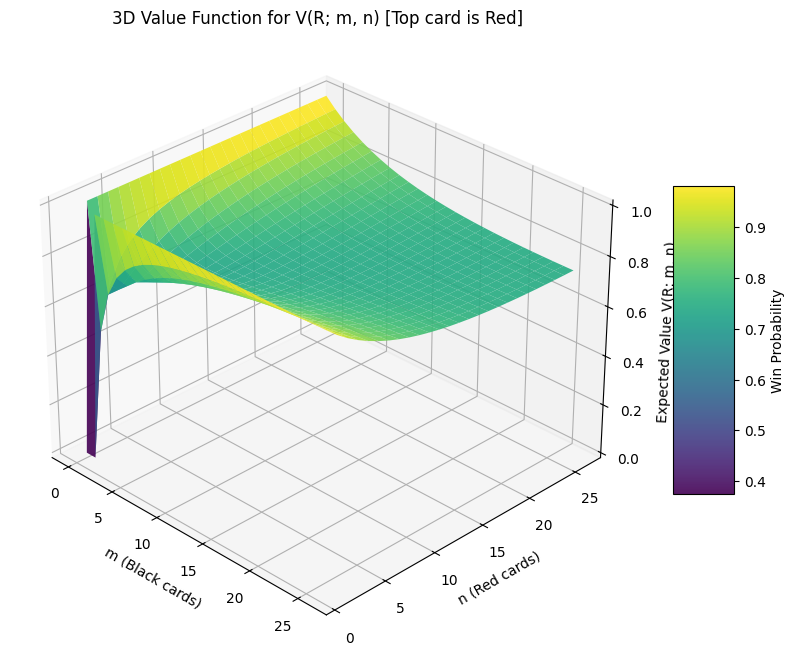

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dictionaries to store already computed values (Memoization)
memo_B = {}
memo_R = {}

def V_B(m, n):
    # Base cases: if no black cards left for the top, or less than 2 cards total, win prob is 0
    if m == 0 or m + n <= 1:
        return 0.0
    if (m, n) in memo_B:
        return memo_B[(m, n)]

    k = m + n
    stop_val = (m - 1) / (k - 1)

    if k > 2:
        continue_val = ((m - 1) / (k - 1)) * V_B(m - 1, n) + (n / (k - 1)) * V_R(m - 1, n)
    else:
        continue_val = 0.0

    memo_B[(m, n)] = max(stop_val, continue_val)
    return memo_B[(m, n)]

def V_R(m, n):
    # Base cases: if no red cards left for the top, or less than 2 cards total, win prob is 0
    if n == 0 or m + n <= 1:
        return 0.0
    if (m, n) in memo_R:
        return memo_R[(m, n)]

    k = m + n
    stop_val = (n - 1) / (k - 1)

    if k > 2:
        continue_val = (m / (k - 1)) * V_B(m, n - 1) + ((n - 1) / (k - 1)) * V_R(m, n - 1)
    else:
        continue_val = 0.0

    memo_R[(m, n)] = max(stop_val, continue_val)
    return memo_R[(m, n)]

# Generate grid for m (0 to 26) and n (1 to 26 since top is Red)
M_vals = np.arange(0, 27)
N_vals = np.arange(1, 27)
M_grid, N_grid = np.meshgrid(M_vals, N_vals)
V_grid = np.zeros_like(M_grid, dtype=float)

# Compute V(R; m, n) for all points in the grid
for i in range(M_grid.shape[0]):
    for j in range(M_grid.shape[1]):
        V_grid[i, j] = V_R(M_grid[i, j], N_grid[i, j])

# Plot the 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(M_grid, N_grid, V_grid, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('m (Black cards)')
ax.set_ylabel('n (Red cards)')
ax.set_zlabel('Expected Value V(R; m, n)')
ax.set_title('3D Value Function for V(R; m, n) [Top card is Red]')

# Add a color bar map
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Win Probability')
ax.view_init(elev=30, azim=-45) # Adjust viewing angle
plt.show()

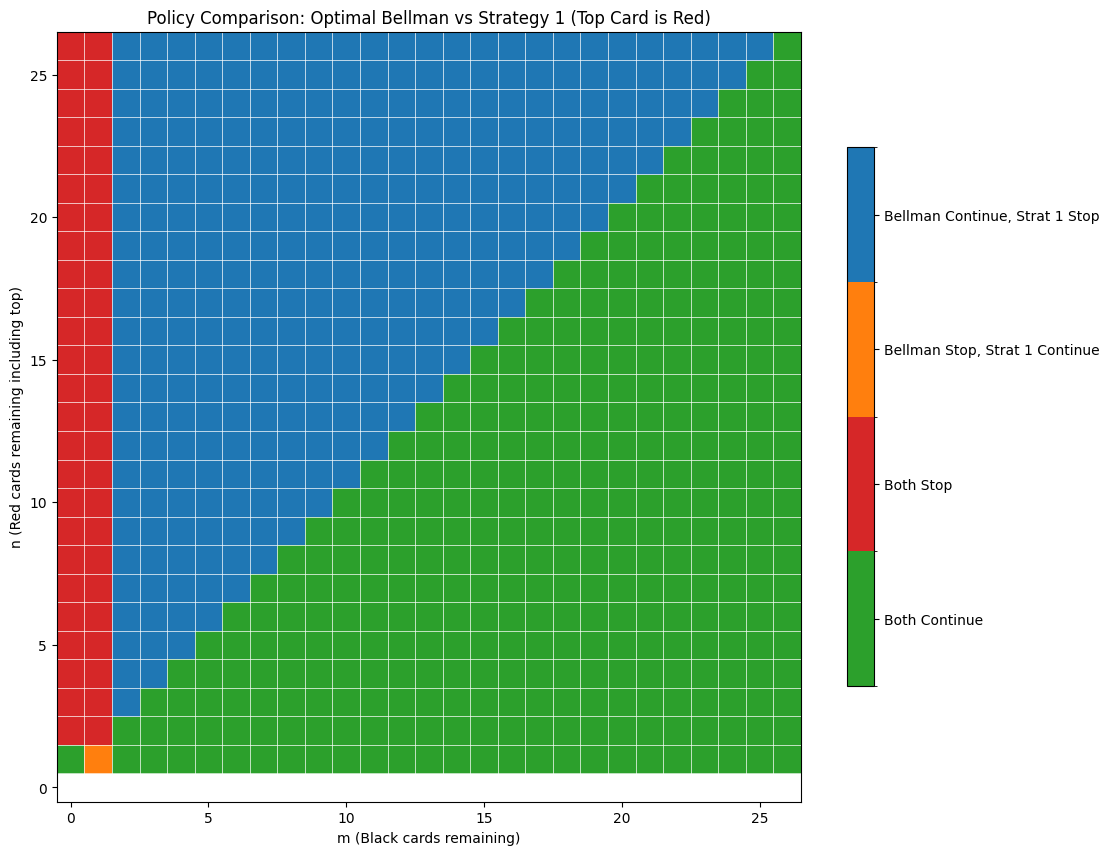

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Maximum number of cards
m_max = 26
n_max = 26

# Matrix to hold policy comparison results
# 0 = Both Continue
# 1 = Both Stop
# 2 = Bellman Stop, Strategy 1 Continue
# 3 = Bellman Continue, Strategy 1 Stop
policy_comparison = np.zeros((m_max + 1, n_max + 1))

# Evaluate both policies for all (m, n) states
for m in range(m_max + 1):
    for n in range(1, n_max + 1):  # n starts from 1 because the top card is Red
        k = m + n
        if k <= 1:
            continue

        # Bellman Equation Policy
        stop_val = (n - 1) / (k - 1)
        if k > 2:
            continue_val = (m / (k - 1)) * V_B(m, n - 1) + ((n - 1) / (k - 1)) * V_R(m, n - 1)
        else:
            continue_val = 0.0

        # Use a small epsilon to account for floating-point inaccuracies
        bellman_stop = stop_val >= continue_val - 1e-9

        # Strategy 1 Policy:
        # Stop if rest.count(top) / len(rest) >= 0.5
        # => (n - 1) / (m + n - 1) >= 0.5 => n - 1 >= m
        strat1_stop = (n - 1) >= m

        # Categorize the state
        if bellman_stop and strat1_stop:
            policy_comparison[m, n] = 1
        elif not bellman_stop and not strat1_stop:
            policy_comparison[m, n] = 0
        elif bellman_stop and not strat1_stop:
            policy_comparison[m, n] = 2
        elif not bellman_stop and strat1_stop:
            policy_comparison[m, n] = 3

# Mask out the n=0 row because we are analyzing Top=Red (requires at least 1 Red)
mask = np.zeros_like(policy_comparison, dtype=bool)
mask[:, 0] = True
policy_masked = np.ma.masked_array(policy_comparison, mask)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Define the discrete colors
cmap = mcolors.ListedColormap(['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Note: Transpose the matrix so m is on x-axis and n is on y-axis
im = ax.imshow(policy_masked.T, origin='lower', cmap=cmap, norm=norm, aspect='auto')

# Add the color legend
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels([
    'Both Continue',
    'Both Stop',
    'Bellman Stop, Strat 1 Continue',
    'Bellman Continue, Strat 1 Stop'
])

ax.set_xlabel('m (Black cards remaining)')
ax.set_ylabel('n (Red cards remaining including top)')
ax.set_title('Policy Comparison: Optimal Bellman vs Strategy 1 (Top Card is Red)')

# Draw grid lines for clarity
ax.set_xticks(np.arange(-0.5, m_max + 1, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_max + 1, 1), minor=True)
ax.grid(which='minor', color='w', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.show()


In [ ]:
def strategy2(shuffled_cards):
  cards = shuffled_cards.copy()

  while len(cards) > 3:
    cards.pop()

  top = cards[-1]
  remains = cards[:-1]
  if cards.count(top) == 3:
    return True

  if remains.count(top) == 0:
    return True

  return top == remains[-1]

In [ ]:
def play(shuffled_cards):
  n = len(shuffled_cards)

  for i in range(n):
    if strategy2(shuffled_cards[0]) == "STOP":
      return shuffled_cards[0][]

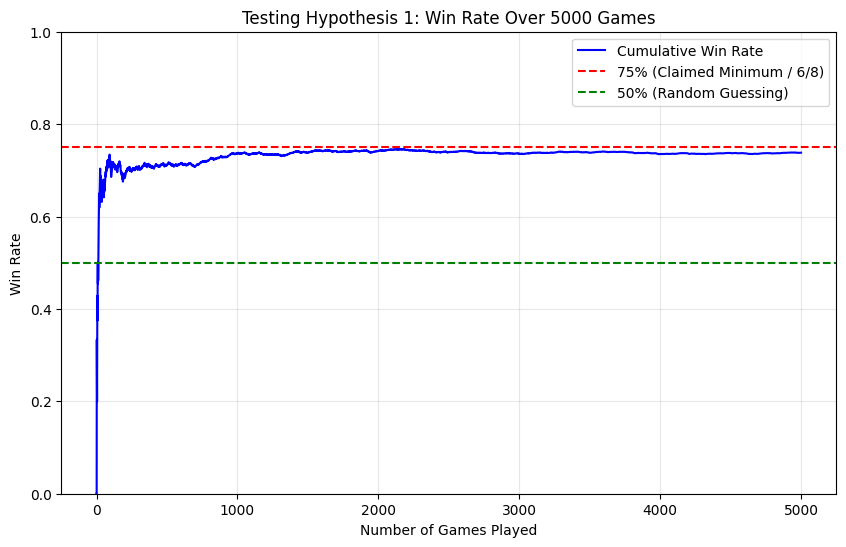

Final Win Rate after 5000 games: 0.7382


In [ ]:
import matplotlib.pyplot as plt

num_games = 5000
wins = 0
win_rates = []

# Run the simulation for 5000 games and track the win rate as we go
for i in range(1, num_games + 1):
  cards = generate_shuffled_deck()

  if strategy2(cards):
    wins += 1
  win_rates.append(wins / i)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(win_rates, label='Cumulative Win Rate', color='blue')

# Add reference lines for 75% (hypothesis) and 50% (actual)
plt.axhline(y=0.75, color='red', linestyle='--', label='75% (Claimed Minimum / 6/8)')
plt.axhline(y=0.50, color='green', linestyle='--', label='50% (Random Guessing)')

plt.ylim(0, 1.0)
plt.xlabel('Number of Games Played')
plt.ylabel('Win Rate')
plt.title('Testing Hypothesis 1: Win Rate Over 5000 Games')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Win Rate after {num_games} games: {win_rates[-1]:.4f}")

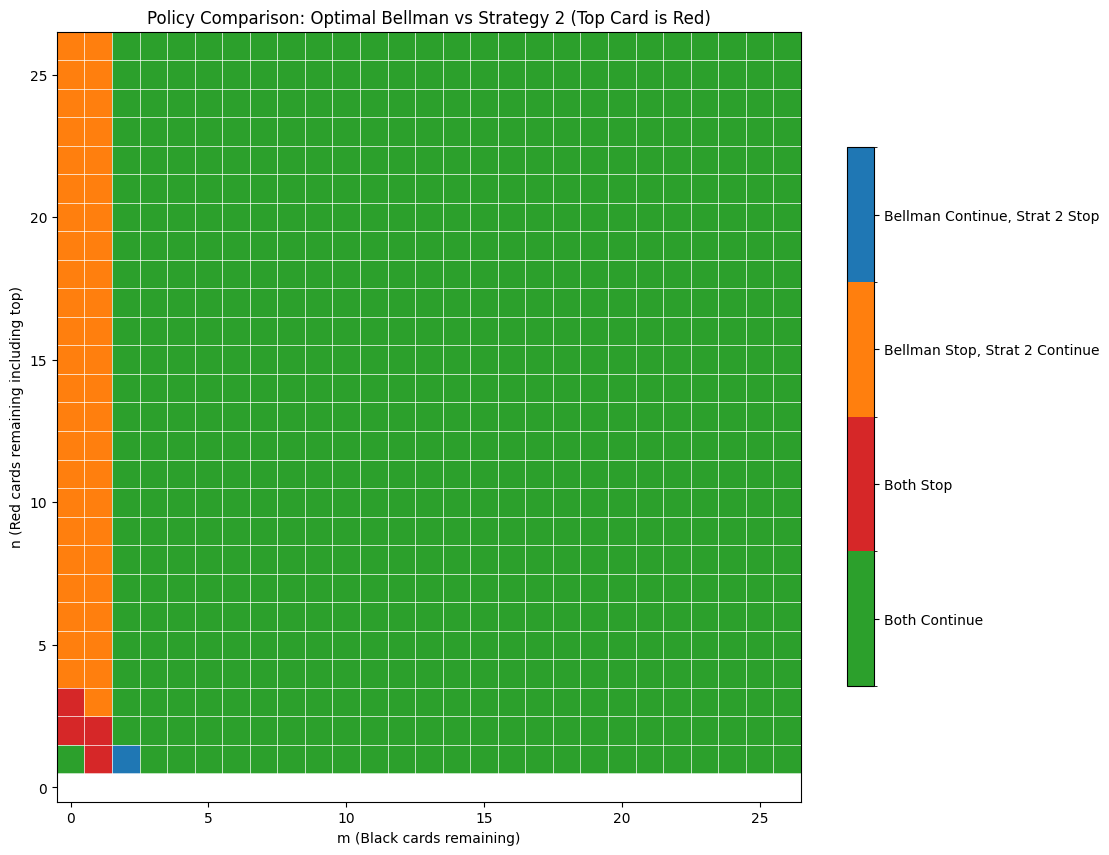

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Dictionaries to store already computed values (Memoization)
memo_B = {}
memo_R = {}

def V_B(m, n):
    if m == 0 or m + n <= 1:
        return 0.0
    if (m, n) in memo_B:
        return memo_B[(m, n)]
    k = m + n
    stop_val = (m - 1) / (k - 1)
    if k > 2:
        continue_val = ((m - 1) / (k - 1)) * V_B(m - 1, n) + (n / (k - 1)) * V_R(m - 1, n)
    else:
        continue_val = 0.0
    memo_B[(m, n)] = max(stop_val, continue_val)
    return memo_B[(m, n)]

def V_R(m, n):
    if n == 0 or m + n <= 1:
        return 0.0
    if (m, n) in memo_R:
        return memo_R[(m, n)]
    k = m + n
    stop_val = (n - 1) / (k - 1)
    if k > 2:
        continue_val = (m / (k - 1)) * V_B(m, n - 1) + ((n - 1) / (k - 1)) * V_R(m, n - 1)
    else:
        continue_val = 0.0
    memo_R[(m, n)] = max(stop_val, continue_val)
    return memo_R[(m, n)]

# Maximum number of cards
m_max = 26
n_max = 26

# Matrix to hold policy comparison results
# 0 = Both Continue
# 1 = Both Stop
# 2 = Bellman Stop, Strategy 2 Continue
# 3 = Bellman Continue, Strategy 2 Stop
policy_comparison = np.zeros((m_max + 1, n_max + 1))

# Evaluate both policies for all (m, n) states
for m in range(m_max + 1):
    for n in range(1, n_max + 1):  # n starts from 1 because the top card is Red
        k = m + n
        if k <= 1:
            continue

        # Bellman Equation Policy
        stop_val = (n - 1) / (k - 1)
        if k > 2:
            continue_val = (m / (k - 1)) * V_B(m, n - 1) + ((n - 1) / (k - 1)) * V_R(m, n - 1)
        else:
            continue_val = 0.0

        # Use a small epsilon to account for floating-point inaccuracies
        bellman_stop = stop_val >= continue_val - 1e-9

        # Strategy 2 Policy:
        # Always continue until 3 or fewer cards remain
        strat2_stop = (k <= 3)

        # Categorize the state
        if bellman_stop and strat2_stop:
            policy_comparison[m, n] = 1
        elif not bellman_stop and not strat2_stop:
            policy_comparison[m, n] = 0
        elif bellman_stop and not strat2_stop:
            policy_comparison[m, n] = 2
        elif not bellman_stop and strat2_stop:
            policy_comparison[m, n] = 3

# Mask out the n=0 row because we are analyzing Top=Red (requires at least 1 Red)
mask = np.zeros_like(policy_comparison, dtype=bool)
mask[:, 0] = True
policy_masked = np.ma.masked_array(policy_comparison, mask)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Define the discrete colors
cmap = mcolors.ListedColormap(['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Note: Transpose the matrix so m is on x-axis and n is on y-axis
im = ax.imshow(policy_masked.T, origin='lower', cmap=cmap, norm=norm, aspect='auto')

# Add the color legend
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels([
    'Both Continue',
    'Both Stop',
    'Bellman Stop, Strat 2 Continue',
    'Bellman Continue, Strat 2 Stop'
])

ax.set_xlabel('m (Black cards remaining)')
ax.set_ylabel('n (Red cards remaining including top)')
ax.set_title('Policy Comparison: Optimal Bellman vs Strategy 2 (Top Card is Red)')

# Draw grid lines for clarity
ax.set_xticks(np.arange(-0.5, m_max + 1, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_max + 1, 1), minor=True)
ax.grid(which='minor', color='w', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.show()
